# DepositGuard — Feature Engineering

Builds 10 behavioral risk features on top of the Bank Account Fraud (NeurIPS 2022) `Base.csv` dataset, then evaluates each feature's relationship with `fraud_bool` before saving the augmented dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import Markdown, display

plt.style.use('dark_background')
sns.set_palette("bright")

OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Load Data

Same `float32` / `int8` / `category` dtype optimization as `01_EDA.ipynb`.

In [2]:
categorical_cols = ["payment_type", "employment_status", "housing_status", "source", "device_os"]
int8_cols = ["fraud_bool", "month"]

header_cols = pd.read_csv("../data/Base.csv", nrows=0).columns
float32_cols = [c for c in header_cols if c not in categorical_cols and c not in int8_cols]

dtype_map = {col: "category" for col in categorical_cols}
dtype_map.update({col: "int8" for col in int8_cols})
dtype_map.update({col: "float32" for col in float32_cols})

df = pd.read_csv("../data/Base.csv", dtype=dtype_map)
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Loaded: 1,000,000 rows x 32 columns


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1.0,25.0,40.0,0.006735,102.453712,AA,1059.0,...,0.0,1500.0,0.0,INTERNET,16.224844,linux,1.0,1.0,0.0,0
1,0,0.8,0.617426,-1.0,89.0,20.0,0.010095,-0.849551,AD,1658.0,...,0.0,1500.0,0.0,INTERNET,3.363854,other,1.0,1.0,0.0,0
2,0,0.8,0.996707,9.0,14.0,40.0,0.012316,-1.490386,AB,1095.0,...,0.0,200.0,0.0,INTERNET,22.730558,windows,0.0,1.0,0.0,0
3,0,0.6,0.475100,11.0,14.0,30.0,0.006991,-1.863101,AB,3483.0,...,0.0,200.0,0.0,INTERNET,15.215816,linux,1.0,1.0,0.0,0
4,0,0.9,0.842307,-1.0,29.0,40.0,5.742626,47.152496,AA,2339.0,...,0.0,200.0,0.0,INTERNET,3.743048,other,0.0,1.0,0.0,0


## Feature 1 — `income_ratio`

`proposed_credit_limit / (income + 1)`. Measures how large a credit line was requested relative to the applicant's income percentile. A high ratio (large credit ask vs. low reported income) is a classic over-reach signal associated with fraudulent applications.

In [3]:
df["income_ratio"] = df["proposed_credit_limit"] / (df["income"] + 1)
df["income_ratio"] = df["income_ratio"].astype("float32")

## Feature 2 — `address_stability`

`prev_address_months_count + current_address_months_count`, with missing values treated as 0.

**Data note:** this dataset encodes "unknown" as the sentinel `-1` rather than `NaN`. To honor the spirit of `fillna(0)`, `-1` sentinels are first converted to `NaN` (so they don't corrupt the sum as literal negative months) and then filled with 0. A low value means a short, unstable address history — a common fraud indicator.

In [4]:
prev_addr = df["prev_address_months_count"].replace(-1, np.nan)
curr_addr = df["current_address_months_count"].replace(-1, np.nan)

df["address_stability"] = (prev_addr + curr_addr).fillna(0).astype("float32")

## Feature 3 — `identity_score`

`(name_email_similarity * 0.4) + (phone_home_valid * 0.3) + (phone_mobile_valid * 0.3)`. A weighted composite of identity-verification signals — higher means the applicant's name/email match and contact details check out, i.e. lower identity risk.

In [5]:
df["identity_score"] = (
    df["name_email_similarity"] * 0.4
    + df["phone_home_valid"] * 0.3
    + df["phone_mobile_valid"] * 0.3
).astype("float32")

## Feature 4 — `credit_income_ratio`

`proposed_credit_limit / (annual_inc * 12 + 1)`. This dataset has no `annual_inc` column, so per the fallback rule we substitute the `income` column (the applicant's income-percentile field) in its place. It is a proxy, not a true annualized-income ratio, but still captures credit-limit aggressiveness relative to reported income.

In [6]:
base_income = df["annual_inc"] if "annual_inc" in df.columns else df["income"]

df["credit_income_ratio"] = (df["proposed_credit_limit"] / (base_income * 12 + 1)).astype("float32")

## Feature 5 — `rapid_application`

`1` if `days_since_request < 1` else `0`. Flags applications submitted almost immediately after the underlying request/event, a pattern associated with automated or opportunistic fraud attempts.

In [7]:
df["rapid_application"] = (df["days_since_request"] < 1).astype("int8")

## Feature 6 — `employment_risk`

Ordinal risk encoding of `employment_status`. The category labels in this dataset are anonymized (`CA`, `CB`, `CC`, ...) with no inherent ordering, so we derive the ordinal ranking empirically: categories are ranked by their observed fraud rate and assigned integers `0` (lowest historical fraud rate) through `n-1` (highest).

**Caveat:** this is a target-derived (supervised) encoding computed on the full dataset, which is fine for exploratory feature analysis here but would leak label information if used naively for model training — a future modeling notebook should refit this mapping only on the training fold (or use cross-validated target encoding).

In [8]:
emp_fraud_rate = df.groupby("employment_status", observed=True)["fraud_bool"].mean().sort_values()
emp_risk_map = {cat: rank for rank, cat in enumerate(emp_fraud_rate.index)}

df["employment_risk"] = df["employment_status"].map(emp_risk_map).astype("int8")
emp_fraud_rate

employment_status
CF    0.001930
CE    0.002336
CD    0.003770
CB    0.006891
CA    0.012186
CG    0.015453
CC    0.024684
Name: fraud_bool, dtype: float64

## Feature 7 — `email_risk`

`email_is_free` cast directly to integer. Free email providers are cheap to create in bulk and are a well-known low-cost signal for synthetic identity / fraud rings.

In [9]:
df["email_risk"] = df["email_is_free"].astype("int8")

## Feature 8 — `age_income_peer_deviation`

`(income - age_group_mean) / age_group_std`, grouped by `customer_age`. This dataset already reports `customer_age` in anonymized decade bins (20, 30, 40, ...), so it is used directly as the peer group without further binning. The result is a z-score of how far an applicant's income percentile sits from their age peers' average — large deviations (either direction) can indicate an anomalous or fabricated profile.

In [10]:
age_group_mean = df.groupby("customer_age")["income"].transform("mean")
age_group_std = df.groupby("customer_age")["income"].transform("std").replace(0, np.nan)

df["age_income_peer_deviation"] = ((df["income"] - age_group_mean) / age_group_std).fillna(0).astype("float32")

## Feature 9 — `credit_tier`

`pd.cut(credit_risk_score, bins=5)` encoded as ordinal `0`–`4`, from lowest to highest credit-risk-score band. Bucketing the continuous risk score into tiers makes it easier to read fraud-rate trends and gives tree-based models a coarser, more robust split candidate.

In [11]:
df["credit_tier"] = pd.cut(df["credit_risk_score"], bins=5, labels=[0, 1, 2, 3, 4]).astype("int8")

## Feature 10 — `fraud_risk_index`

An equal-weighted composite of 5 primary risk signals built above: `rapid_application`, `employment_risk`, `email_risk`, `credit_tier`, and `|age_income_peer_deviation|` (absolute deviation, since anomalies in either direction matter). Each is min-max normalized to `[0, 1]` before averaging so no single signal's raw scale dominates the composite.

In [12]:
def minmax(series):
    return (series - series.min()) / (series.max() - series.min() + 1e-9)

df["fraud_risk_index"] = (
    minmax(df["rapid_application"])
    + minmax(df["employment_risk"])
    + minmax(df["email_risk"])
    + minmax(df["credit_tier"])
    + minmax(df["age_income_peer_deviation"].abs())
) / 5
df["fraud_risk_index"] = df["fraud_risk_index"].astype("float32")

## Engineered Feature Summary

In [13]:
new_features = [
    "income_ratio",
    "address_stability",
    "identity_score",
    "credit_income_ratio",
    "rapid_application",
    "employment_risk",
    "email_risk",
    "age_income_peer_deviation",
    "credit_tier",
    "fraud_risk_index",
]

df[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
income_ratio,1000000.0,3.361727e+02,323.928894,100.000000,117.647057,166.666656,454.545441,1909.090820
address_stability,1000000.0,2.333839e+01,57.004784,0.000000,0.000000,0.000000,25.000000,720.000000
identity_score,1000000.0,5.895036e-01,0.191338,0.000192,0.434343,0.596856,0.698020,0.999999
credit_income_ratio,1000000.0,8.830618e+01,115.278038,16.101696,21.276596,47.169811,90.909088,954.545410
rapid_application,1000000.0,9.182670e-01,0.273958,0.000000,1.000000,1.000000,1.000000,1.000000
employment_risk,1000000.0,3.640422e+00,1.084134,0.000000,4.000000,4.000000,4.000000,6.000000
email_risk,1000000.0,5.298860e-01,0.499106,0.000000,0.000000,1.000000,1.000000,1.000000
age_income_peer_deviation,1000000.0,-1.171875e-08,0.999996,-1.826050,-0.929406,0.315698,1.027282,1.646025
credit_tier,1000000.0,2.202167e+00,0.680999,0.000000,2.000000,2.000000,3.000000,4.000000
fraud_risk_index,1000000.0,6.168773e-01,0.135781,0.004483,0.520759,0.612754,0.726867,1.000000


## Fraud Rate by New Feature — High vs. Low

Low-cardinality features (`rapid_application`, `employment_risk`, `email_risk`, `credit_tier`) are broken out by their exact level. Continuous features are split at the median into `Low` (median and below) and `High` (above median) — several of these features (e.g. `address_stability`) are zero-inflated, so the split uses a strict `>` comparison for `High` to avoid an empty bucket when the median itself is a heavily tied value.

In [14]:
low_cardinality = ["rapid_application", "employment_risk", "email_risk", "credit_tier"]

for feature in new_features:
    print(f"--- {feature} ---")
    if feature in low_cardinality:
        rate = df.groupby(feature, observed=True)["fraud_bool"].mean() * 100
    else:
        median = df[feature].median()
        level = np.where(df[feature] > median, "High", "Low")
        rate = df.groupby(level)["fraud_bool"].mean().reindex(["Low", "High"]) * 100
    print(rate.round(3).to_string())
    print()

--- income_ratio ---
Low     0.780
High    1.429

--- address_stability ---
Low     1.415
High    0.311

--- identity_score ---
Low     1.513
High    0.692

--- credit_income_ratio ---
Low     0.893
High    1.329

--- rapid_application ---
rapid_application
0    1.302
1    1.085

--- employment_risk ---
employment_risk
0    0.193
1    0.234
2    0.377
3    0.689
4    1.219
5    1.545
6    2.468

--- email_risk ---
email_risk
0    0.795
1    1.376

--- age_income_peer_deviation ---
Low     0.729
High    1.512

--- credit_tier ---
credit_tier
0    0.332
1    0.577
2    0.723
3    1.736
4    5.421

--- fraud_risk_index ---
Low     0.767
High    1.440



## Correlation of New Features with `fraud_bool`

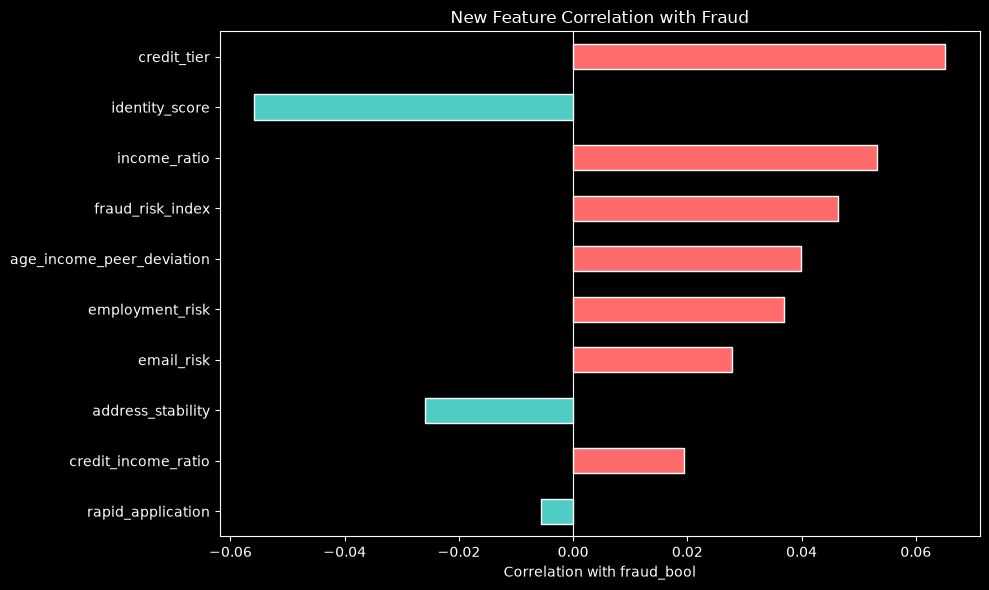

credit_tier                  0.065188
identity_score              -0.055826
income_ratio                 0.053121
fraud_risk_index             0.046444
age_income_peer_deviation    0.039921
employment_risk              0.036960
email_risk                   0.027758
address_stability           -0.025870
credit_income_ratio          0.019401
rapid_application           -0.005682
Name: fraud_bool, dtype: float64

In [15]:
corr_with_target = (
    df[new_features + ["fraud_bool"]]
    .corr()["fraud_bool"]
    .drop("fraud_bool")
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#ff6b6b" if v > 0 else "#4ecdc4" for v in corr_with_target.values]
corr_with_target.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("Correlation with fraud_bool")
ax.set_title("New Feature Correlation with Fraud")
ax.axvline(0, color="white", linewidth=0.8)
plt.tight_layout()
plt.show()

corr_with_target

## Save Feature-Engineered Dataset

In [16]:
output_path = f"{OUTPUT_DIR}/featured_data.csv"
df.to_csv(output_path, index=False)
print(f"Saved {df.shape[0]:,} rows x {df.shape[1]} columns to {output_path}")

Saved 1,000,000 rows x 42 columns to ../outputs/featured_data.csv


## Strongest Fraud Signals

In [17]:
top_n = 5
top_features = corr_with_target.head(top_n)

lines = [f"{i+1}. **`{feat}`** — r = {val:.4f} with `fraud_bool`" for i, (feat, val) in enumerate(top_features.items())]
summary = "\n".join(lines)

display(Markdown(f"""The {top_n} strongest fraud signals among the newly engineered features, ranked by absolute correlation with `fraud_bool`:

{summary}
"""))

The 5 strongest fraud signals among the newly engineered features, ranked by absolute correlation with `fraud_bool`:

1. **`credit_tier`** — r = 0.0652 with `fraud_bool`
2. **`identity_score`** — r = -0.0558 with `fraud_bool`
3. **`income_ratio`** — r = 0.0531 with `fraud_bool`
4. **`fraud_risk_index`** — r = 0.0464 with `fraud_bool`
5. **`age_income_peer_deviation`** — r = 0.0399 with `fraud_bool`
